In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.optimizers import Adam, RMSprop
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,Activation,AlphaDropout
from keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import itertools

In [2]:
# Constants
IMG_SIZE = 48
BATCH_SIZE = 64
TRAIN_DIR = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\train"
VAL_DIR = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\val"
TEST_DIR = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\test"
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [3]:
for emotion_label, emotion in enumerate(EMOTIONS):
    print(emotion_label,emotion)

0 Angry
1 Disgust
2 Fear
3 Happy
4 Neutral
5 Sad
6 Surprise


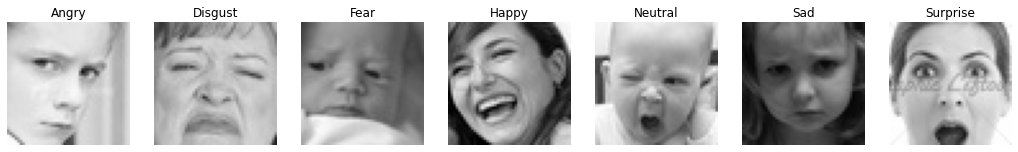

In [4]:
# Function to load images

# Plot the images with each distinct emotions.
plt.figure(figsize=(18,22))
i = 1
for expression in EMOTIONS:
    img = load_img((TRAIN_DIR + '/' + expression +'/'+ os.listdir(TRAIN_DIR + '/' + expression)[59]))
    plt.subplot(1,7,i)
    plt.imshow(img)
    plt.title(expression)
    plt.axis('off')
    i += 1
plt.show()

# Data Preprocessing

In [5]:
# Rescale train data.
datagen_train = ImageDataGenerator(rescale = 1./255,
                                   horizontal_flip=True,
                                   zoom_range=0.3,
                                   rotation_range=20
                                  )

# Rescale validation data.
datagen_val = ImageDataGenerator(rescale = 1./255)

In [6]:
# Training data.
train_set = datagen_train.flow_from_directory(directory=TRAIN_DIR,
                                              target_size=(IMG_SIZE,IMG_SIZE),
                                              batch_size = BATCH_SIZE,
                                              color_mode = 'grayscale',
                                              class_mode = "categorical",
                                              shuffle=True
                                              )

# Validation data.
val_set = datagen_train.flow_from_directory(directory=VAL_DIR,
                                              target_size=(IMG_SIZE,IMG_SIZE),
                                              batch_size = BATCH_SIZE,
                                              color_mode = 'grayscale',
                                              class_mode = "categorical",
                                              shuffle=False
                                              )

print('Train and Validation sets have been created.')

Found 28709 images belonging to 7 classes.
Found 7163 images belonging to 7 classes.
Train and Validation sets have been created.


# Model Training

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,1)))
    
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.1))
    
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.1))
              
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.1))
              
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(7, activation='softmax'))
    
    return model

In [27]:
model = create_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 44, 44, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 22, 22, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 22, 22, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 20, 20, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 10, 10, 128)      0         
 2D)                                                    

In [28]:
model.compile(
    optimizer = Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
  )

print('CNN model has been created you can proceed to train you data with this model.')

CNN model has been created you can proceed to train you data with this model.


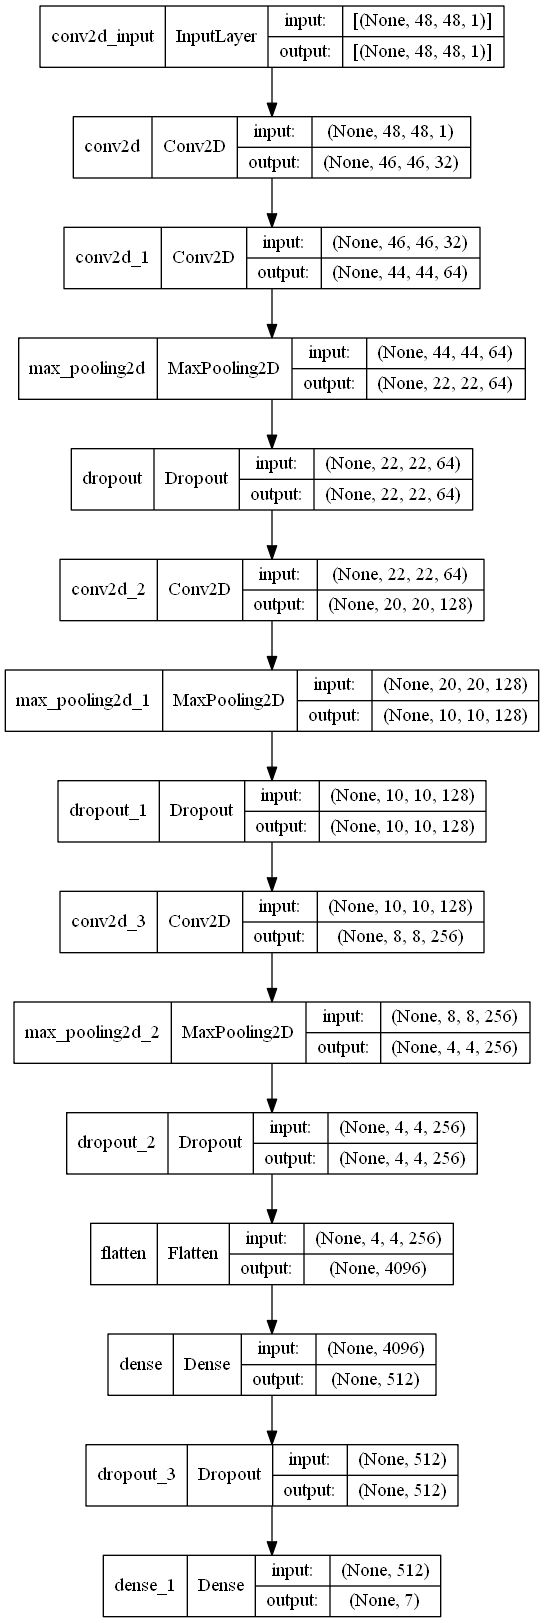

In [29]:
# Visualize the model.
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

### Define Callback 

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Add EarlyStopping callback
early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=0
    )

### Now lets fit the data to our model.

In [11]:
history = model.fit(train_set,
                              steps_per_epoch=train_set.n//train_set.batch_size,
                              validation_data = val_set,
                              validation_steps=val_set.n//val_set.batch_size,
                              epochs = 50,
                              callbacks=[early_stop])

print('Your model has been trained!!')

Epoch 1/50
448/448 [==============================] - 271s 600ms/step - loss: 1.7568 - accuracy: 0.2781 - val_loss: 1.7161 - val_accuracy: 0.2827
Epoch 2/50
448/448 [==============================] - 260s 580ms/step - loss: 1.6026 - accuracy: 0.3686 - val_loss: 1.5205 - val_accuracy: 0.4169
Epoch 3/50
448/448 [==============================] - 285s 637ms/step - loss: 1.4604 - accuracy: 0.4360 - val_loss: 1.3758 - val_accuracy: 0.4651
Epoch 4/50
448/448 [==============================] - 281s 627ms/step - loss: 1.3701 - accuracy: 0.4729 - val_loss: 1.3339 - val_accuracy: 0.4925
Epoch 5/50
448/448 [==============================] - 306s 682ms/step - loss: 1.3184 - accuracy: 0.4946 - val_loss: 1.2892 - val_accuracy: 0.4986
Epoch 6/50
448/448 [==============================] - 285s 635ms/step - loss: 1.2786 - accuracy: 0.5134 - val_loss: 1.2632 - val_accuracy: 0.5163
Epoch 7/50
448/448 [==============================] - 296s 662ms/step - loss: 1.2455 - accuracy: 0.5297 - val_loss: 1.2197 -

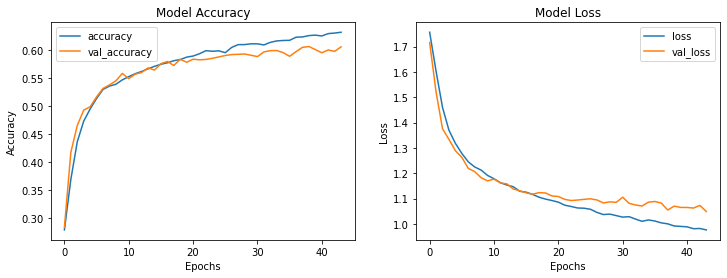

In [12]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Create confusion matrix of our predictions

# compute predictions
predictions = model.predict(val_set)
y_pred = [np.argmax(probas) for probas in predictions]
y_test = val_set.classes
class_names = val_set.class_indices.keys()

In [29]:
# Create function to plot confussion matrix.
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(12,6), dpi=120)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

<Figure size 432x288 with 0 Axes>

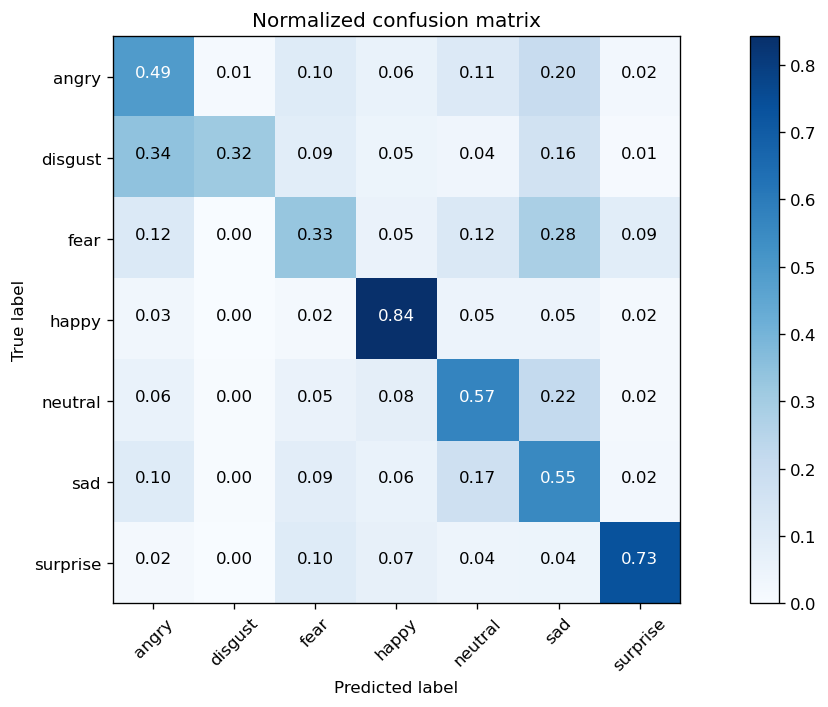

In [13]:
# Compute confusion matrix for validation data
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Normalized confusion matrix')
plt.show()

In [21]:
model.save('model_base1.h5')

In [22]:
model.save_weights('model_weights_base1.h5')

# Model Evaluation

In [7]:
import tensorflow as tf
from tensorflow import keras
import os

model = tf.keras.models.load_model('model_base1.h5')
label_dict = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Neutral',5:'Sad',6:'Surprise'}

X_test = []
y_test = []

for filename in os.listdir(TEST_DIR):
    if filename.endswith(".jpg"):
        # Full path to the image
        img_path = os.path.join(TEST_DIR, filename)
        
        # Read the image
        img = cv2.imread(img_path)

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to 48x48
        resized = cv2.resize(gray, (48, 48))

        # Add to the list
        X_test.append(resized)

        # Extract label (part before the underscore)
        label = filename.split("_")[0]
        y_test.append(label)

# Convert to numpy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = X_test.reshape(-1, 48, 48, 1)  # Ensure shape is (16, 48, 48, 1)
X_test = X_test.astype("float32") / 255.0  # Normalize pixel values to [0, 1]

# Invert the label_dict
label_to_index = {v: k for k, v in label_dict.items()}

# Convert label names to indices
y_test_indices = np.array([label_to_index[label] for label in y_test])
# One-hot encode
y_test_encoded = to_categorical(y_test_indices, num_classes=len(label_dict))


In [8]:
# Model Evaluation
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

In [9]:
y_pred_classes

array([0, 2, 0, 5, 0, 0, 0, 5, 1, 1, 1, 6, 2, 5, 6, 2, 2, 0, 3, 3, 3, 3,
       3, 3, 0, 3, 3, 3, 4, 4, 5, 4, 4, 4, 4, 5, 5, 5, 5, 5, 4, 0, 6, 6,
       6], dtype=int64)

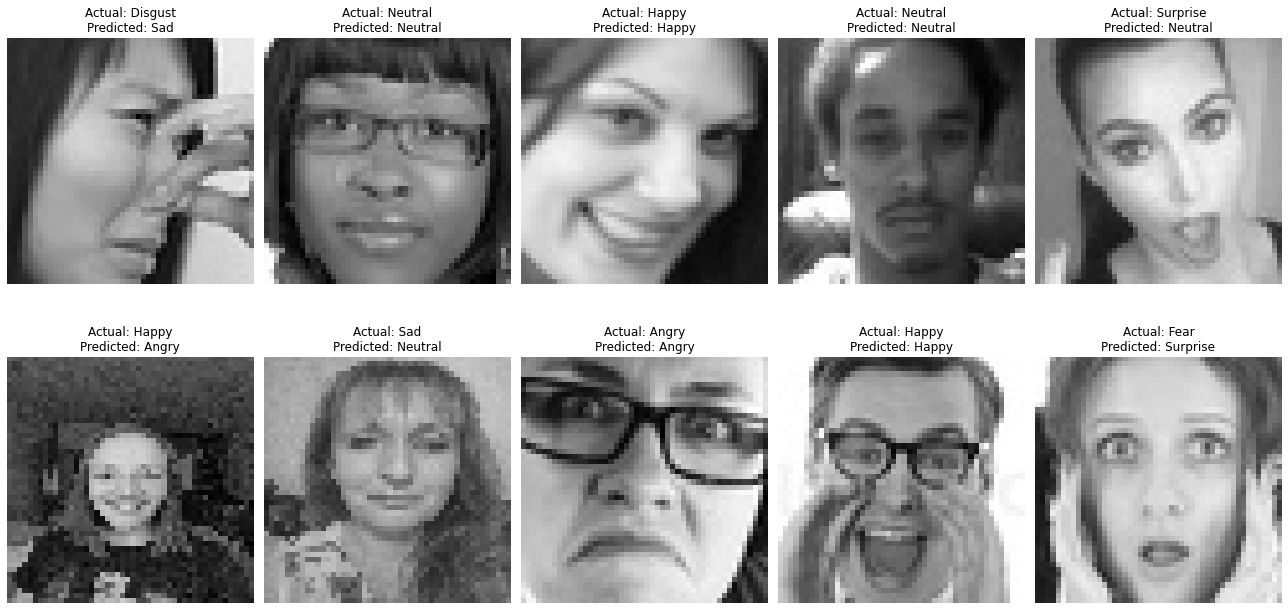

In [10]:
# Display images with predicted and actual labels
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

# Randomly select 20 indices from X_test
num_images = min(10, len(X_test))
random_indices = random.sample(range(len(X_test)), num_images)

plt.figure(figsize=(18, 18))

for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)
    img = (X_test[idx] * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Actual: {EMOTIONS[y_true[idx]]}\nPredicted: {EMOTIONS[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Test Accuracy with the base model

In [11]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.67


## Hyper Parameter Tuning

### Objective function for Optuna

In [12]:
def objective(trial):
    # Hyperparameter search space
    dense_units = trial.suggest_int('dense_units', 64, 256, step=64)
    dropout_rate = trial.suggest_float('dropout_rate',0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,1)))
    
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
    
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
              
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
              
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(7, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
              
    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=10,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Return validation accuracy
    val_acc = history.history['val_accuracy'][-1]
    return val_acc


### Run Optuna Study

In [15]:
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)  


[I 2025-04-14 07:58:55,192] A new study created in memory with name: no-name-84252bba-0e03-4b9a-9cfe-45756f767715
[I 2025-04-14 08:20:41,341] Trial 0 finished with value: 0.4701940417289734 and parameters: {'dense_units': 64, 'dropout_rate': 0.4764846263098109, 'learning_rate': 0.0006847576105287999, 'batch_size': 64}. Best is trial 0 with value: 0.4701940417289734.
[I 2025-04-14 08:42:10,838] Trial 1 finished with value: 0.5312020182609558 and parameters: {'dense_units': 128, 'dropout_rate': 0.31612570756657765, 'learning_rate': 0.0009229737677437131, 'batch_size': 64}. Best is trial 1 with value: 0.5312020182609558.
[I 2025-04-14 09:05:01,987] Trial 2 finished with value: 0.5071897506713867 and parameters: {'dense_units': 192, 'dropout_rate': 0.12978058634950995, 'learning_rate': 0.00013840551197878264, 'batch_size': 64}. Best is trial 1 with value: 0.5312020182609558.
[I 2025-04-14 09:27:15,998] Trial 3 finished with value: 0.4718693196773529 and parameters: {'dense_units': 64, 'dro

### Best Hyper Parameters

In [17]:
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Best hyperparameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Accuracy: 0.5529806017875671
  Best hyperparameters:
    dense_units: 192
    dropout_rate: 0.10504893311227131
    learning_rate: 0.00044000050917227527
    batch_size: 32


### Train the Model using the best hyperparameters.

In [24]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,1)))
    
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(trial.params['dropout_rate']))
    
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(trial.params['dropout_rate']))
              
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(trial.params['dropout_rate']))
              
model.add(Flatten())
model.add(Dense(trial.params['dense_units'], activation='relu'))
model.add(Dropout(trial.params['dropout_rate']))
model.add(Dense(7, activation='softmax'))

model.summary()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_92 (Conv2D)          (None, 46, 46, 32)        320       
                                                                 
 conv2d_93 (Conv2D)          (None, 44, 44, 64)        18496     
                                                                 
 max_pooling2d_69 (MaxPoolin  (None, 22, 22, 64)       0         
 g2D)                                                            
                                                                 
 dropout_92 (Dropout)        (None, 22, 22, 64)        0         
                                                                 
 conv2d_94 (Conv2D)          (None, 20, 20, 128)       73856     
                                                                 
 max_pooling2d_70 (MaxPoolin  (None, 10, 10, 128)      0         
 g2D)                                                

In [25]:
model.compile(optimizer=Adam(learning_rate=trial.params['learning_rate']), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
              
history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=30,
        batch_size=trial.params['batch_size'],
        callbacks=[early_stop]
    )

Epoch 1/50
449/449 [==============================] - 130s 289ms/step - loss: 1.7701 - accuracy: 0.2737 - val_loss: 1.6866 - val_accuracy: 0.3327
Epoch 2/50
449/449 [==============================] - 140s 312ms/step - loss: 1.6188 - accuracy: 0.3639 - val_loss: 1.5393 - val_accuracy: 0.4113
Epoch 3/50
449/449 [==============================] - 151s 336ms/step - loss: 1.5012 - accuracy: 0.4224 - val_loss: 1.4342 - val_accuracy: 0.4518
Epoch 4/50
449/449 [==============================] - 153s 342ms/step - loss: 1.4037 - accuracy: 0.4606 - val_loss: 1.3721 - val_accuracy: 0.4733
Epoch 5/50
449/449 [==============================] - 160s 356ms/step - loss: 1.3484 - accuracy: 0.4849 - val_loss: 1.3012 - val_accuracy: 0.4949
Epoch 6/50
449/449 [==============================] - 160s 356ms/step - loss: 1.2962 - accuracy: 0.5080 - val_loss: 1.2608 - val_accuracy: 0.5214
Epoch 7/50
449/449 [==============================] - 164s 364ms/step - loss: 1.2606 - accuracy: 0.5174 - val_loss: 1.2354 -

### Training History after HyperParameter Tuning

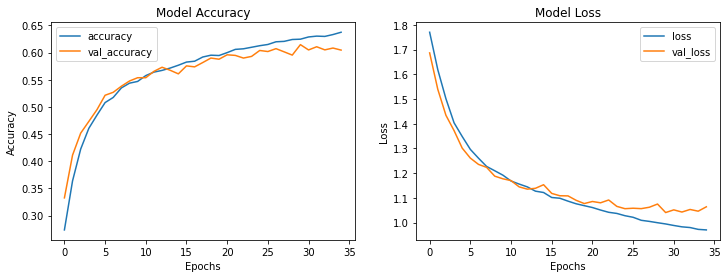

In [27]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 432x288 with 0 Axes>

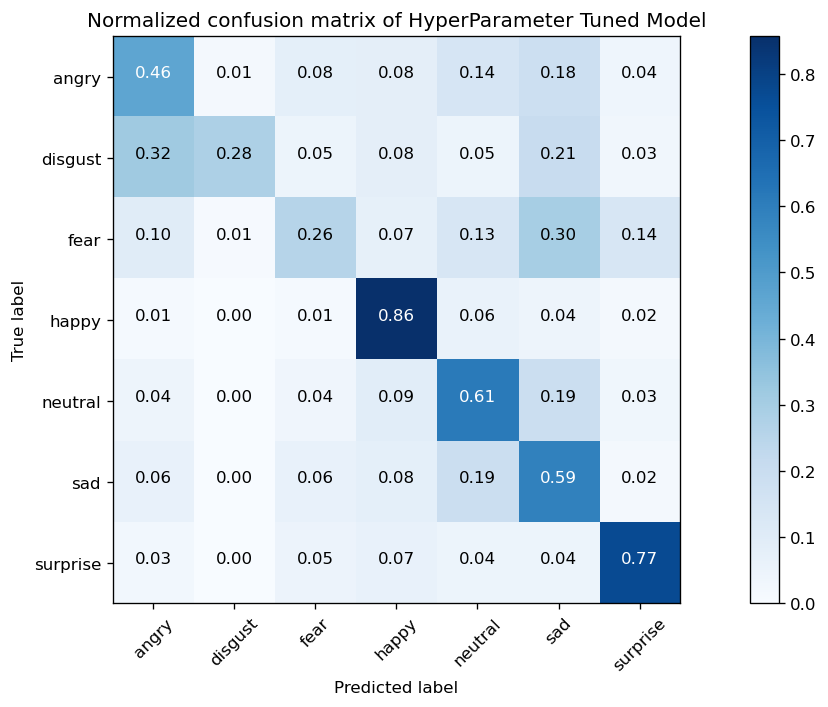

In [30]:
# Create confusion matrix of our predictions

# compute predictions
predictions = model.predict(val_set)
y_pred = [np.argmax(probas) for probas in predictions]
y_test = val_set.classes
class_names = val_set.class_indices.keys()

# Compute confusion matrix for validation data
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Normalized confusion matrix of HyperParameter Tuned Model')
plt.show()

In [31]:
model.save('model_tuned.h5')

In [32]:
model.save_weights('model_weights_tuned.h5')

# Model Evaluation

In [42]:
model = tf.keras.models.load_model('model_tuned.h5')
history.history['val_accuracy'][-1]

0.6044953465461731

In [33]:
model = tf.keras.models.load_model('model_tuned.h5')
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

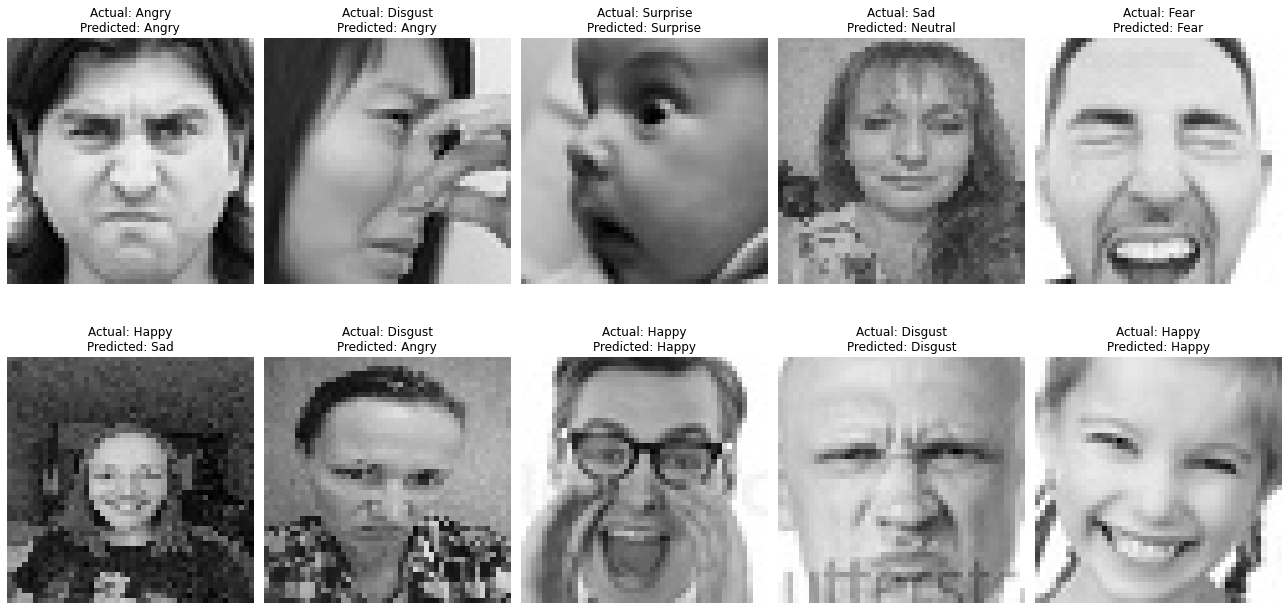

In [40]:
# Display images with predicted and actual labels
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

# Randomly select 20 indices from X_test
num_images = min(10, len(X_test))
random_indices = random.sample(range(len(X_test)), num_images)

plt.figure(figsize=(18, 18))

for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)
    img = (X_test[idx] * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Actual: {EMOTIONS[y_true[idx]]}\nPredicted: {EMOTIONS[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### Test Accuracy with the tuned model

In [36]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.60
